In [26]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi
#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os,sys
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

In [27]:
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

In [28]:
path = os.path.join(os.getcwd(), 'titanic.csv')
df = pd.read_csv(path)


In [29]:
print(df.columns.values)
print(df.info())

['survived' 'pclass' 'sex' 'age' 'sibsp' 'parch' 'fare' 'embarked' 'class'
 'who' 'adult_male' 'deck' 'embark_town' 'alive' 'alone']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)

In [30]:
print(df.describe())

         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


#### To check for duplicate rows

In [31]:
# Check for duplicate rows
duplicates = df[df.duplicated()]

# Summary
print(f"Total duplicate rows: {len(duplicates)}")
print("\nDuplicate rows:\n", duplicates)
print(f'Duplicate Index number: {duplicates.index.values}')

Total duplicate rows: 107

Duplicate rows:
      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
47          1       3  female   NaN      0      0   7.7500        Q   Third   
76          0       3    male   NaN      0      0   7.8958        S   Third   
77          0       3    male   NaN      0      0   8.0500        S   Third   
87          0       3    male   NaN      0      0   8.0500        S   Third   
95          0       3    male   NaN      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
870         0       3    male  26.0      0      0   7.8958        S   Third   
877         0       3    male  19.0      0      0   7.8958        S   Third   
878         0       3    male   NaN      0      0   7.8958        S   Third   
884         0       3    male  25.0      0      0   7.0500        S   Third   
886         0       2    male  27.0      0      0  13.0000        S  Second   

       

### Check for missing value

In [39]:
# Check for missing value
ser = df.isnull().sum()
ser.name = 'NullCount'
dfNull = ser.to_frame()
tableDispFormatt('Null count')
print(dfNull[dfNull['NullCount']!=0])
has_categorical = df.select_dtypes(include=['object', 'category']).columns.to_list()
has_numerical_cols = df.select_dtypes(include='number').columns.tolist()
your_data_list = dfNull[dfNull['NullCount']!=0].index.to_list()
print(f'Total size of Dataset: {df.shape[0]}')
print(f'Null count present in categorical col: {list(set(has_categorical) & set(your_data_list))}')
print(f'Null count present in Numerical col: {list(set(has_numerical_cols) & set(your_data_list))}')
tableDispFormatt('Null count by Index number')
NullIndex = []
for clm in df.columns.values:
    NullIndex = df[df[clm].isnull() == True].index.values
    if len(NullIndex)!=0:
        pass
        #print(f'Index numbers\n: {NullIndex}')
    else:
        pass
        #print(f'not null present in regressosr variablr {clm}')

=============================== Null count =================================================
             NullCount
age                177
embarked             2
deck               688
embark_town          2
Total size of Dataset: 891
Null count present in categorical col: ['deck', 'embarked', 'embark_town']
Null count present in Numerical col: ['age']
=============================== Null count by Index number =================================


### Check if CategoricalDtype present

In [33]:
print(f'Data type:\n{df.dtypes}')
tableDispFormatt('Check categeriocal')
# Method 1: Check Data type categeriocal
#for col in df.columns:
#    if isinstance(df[col].dtype, pd.CategoricalDtype):
#        print(f"{col} is categorical")
        
# Method 2: Check Data type categeriocal
for col in df.select_dtypes(include='object'):
    tableDispFormatt(f'Regressor Variable: {col}')
    print(f"{df[col].value_counts()}")

Data type:
survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embarked        object
class           object
who             object
adult_male        bool
deck            object
embark_town     object
alive           object
alone             bool
dtype: object
=============================== Check categeriocal =========================================
=============================== Regressor Variable: sex ====================================
sex
male      577
female    314
Name: count, dtype: int64
=============================== Regressor Variable: embarked ===============================
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
=============================== Regressor Variable: class ==================================
class
Third     491
First     216
Second    184
Name: count, dtype: int64
=============================== Regressor Variable: who ========

### Explore Categorical variable

In [37]:
CatDataset = df.select_dtypes(include=['object', 'category'])
cols = CatDataset.columns.to_list()
for i in cols:
    print(f'{i} has value count {df[i].value_counts()}')

sex has value count sex
male      577
female    314
Name: count, dtype: int64
embarked has value count embarked
S    644
C    168
Q     77
Name: count, dtype: int64
class has value count class
Third     491
First     216
Second    184
Name: count, dtype: int64
who has value count who
man      537
woman    271
child     83
Name: count, dtype: int64
deck has value count deck
C    59
B    47
D    33
E    32
A    15
F    13
G     4
Name: count, dtype: int64
embark_town has value count embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
alive has value count alive
no     549
yes    342
Name: count, dtype: int64


### Explore Numerical Variables

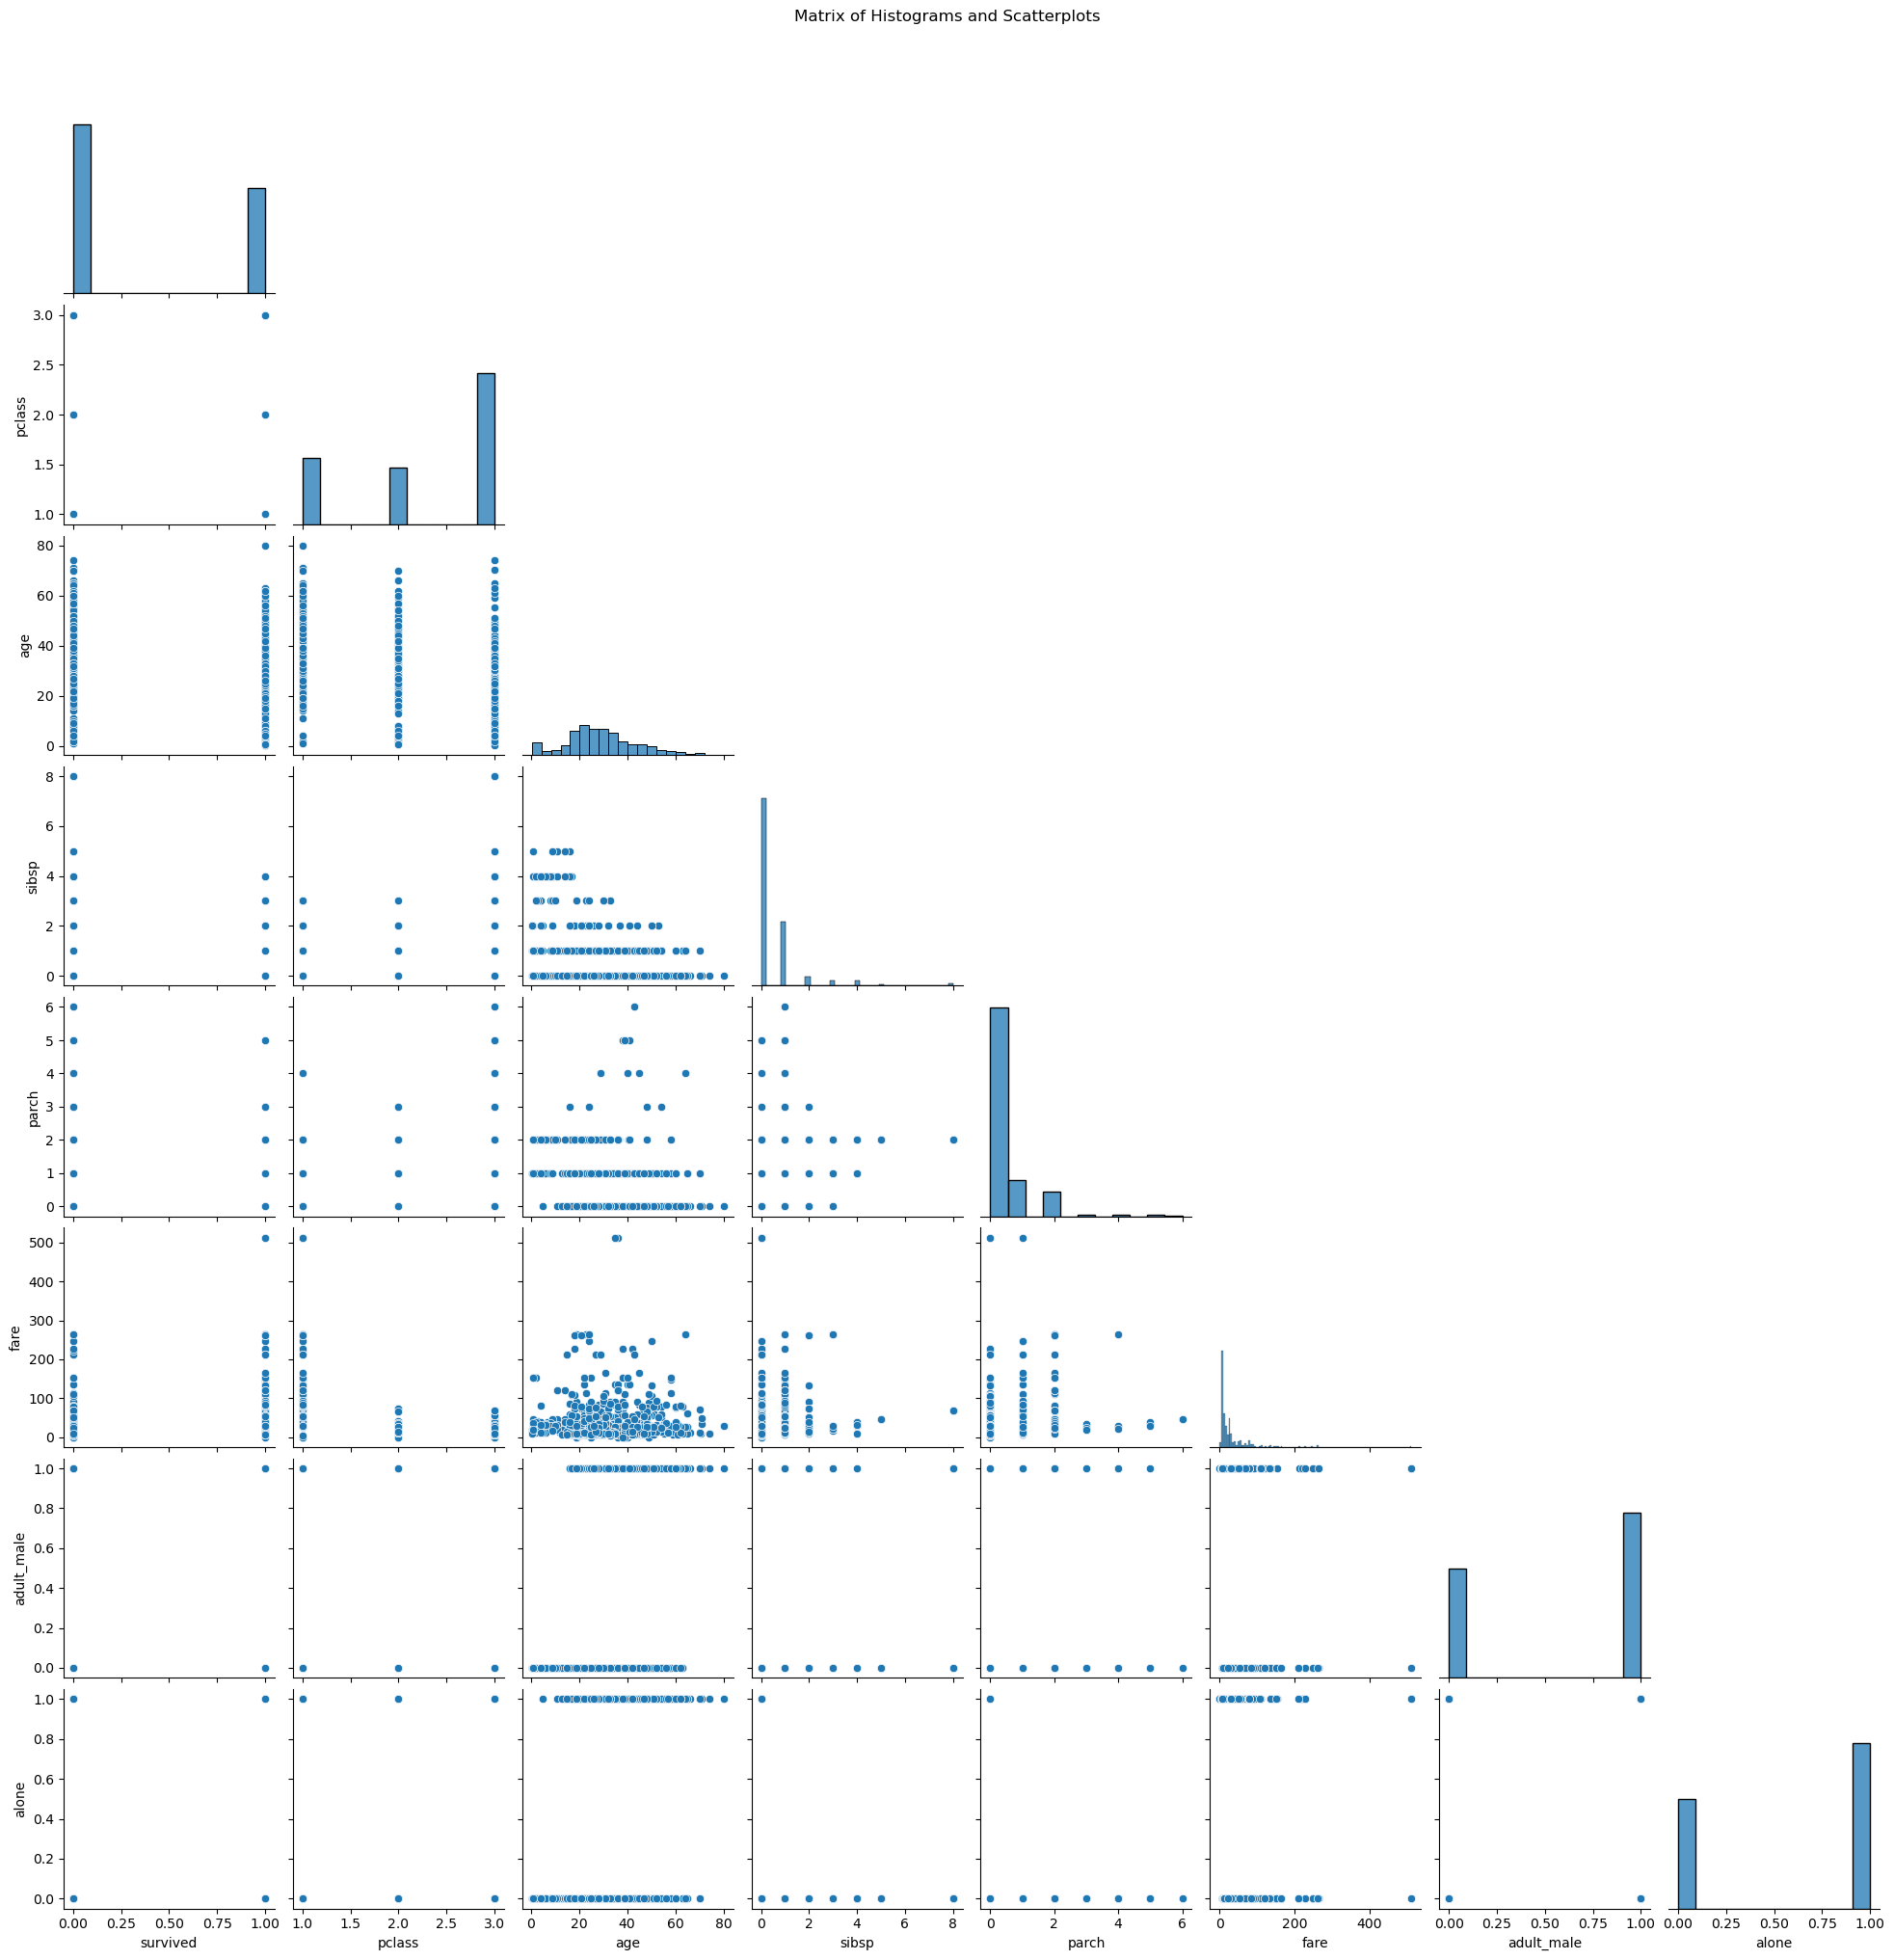

In [ ]:
sns.pairplot(df, diag_kind='hist', corner=True,)
plt.suptitle("Matrix of Histograms and Scatterplots", y=1.02)
plt.show()


### check skewness and kurtosis of a dataset

**Skewness**: Measures asymmetry of the distribution.
- Positive skew → tail on the right
- Negative skew → tail on the left

**Kurtosis**: Measures tailedness or peakedness.
- High kurtosis → heavy tails (outliers)
- Low kurtosis → light tails (flat distribution)
- Normal distribution has kurtosis ≈ 3 (excess kurtosis ≈ 0)


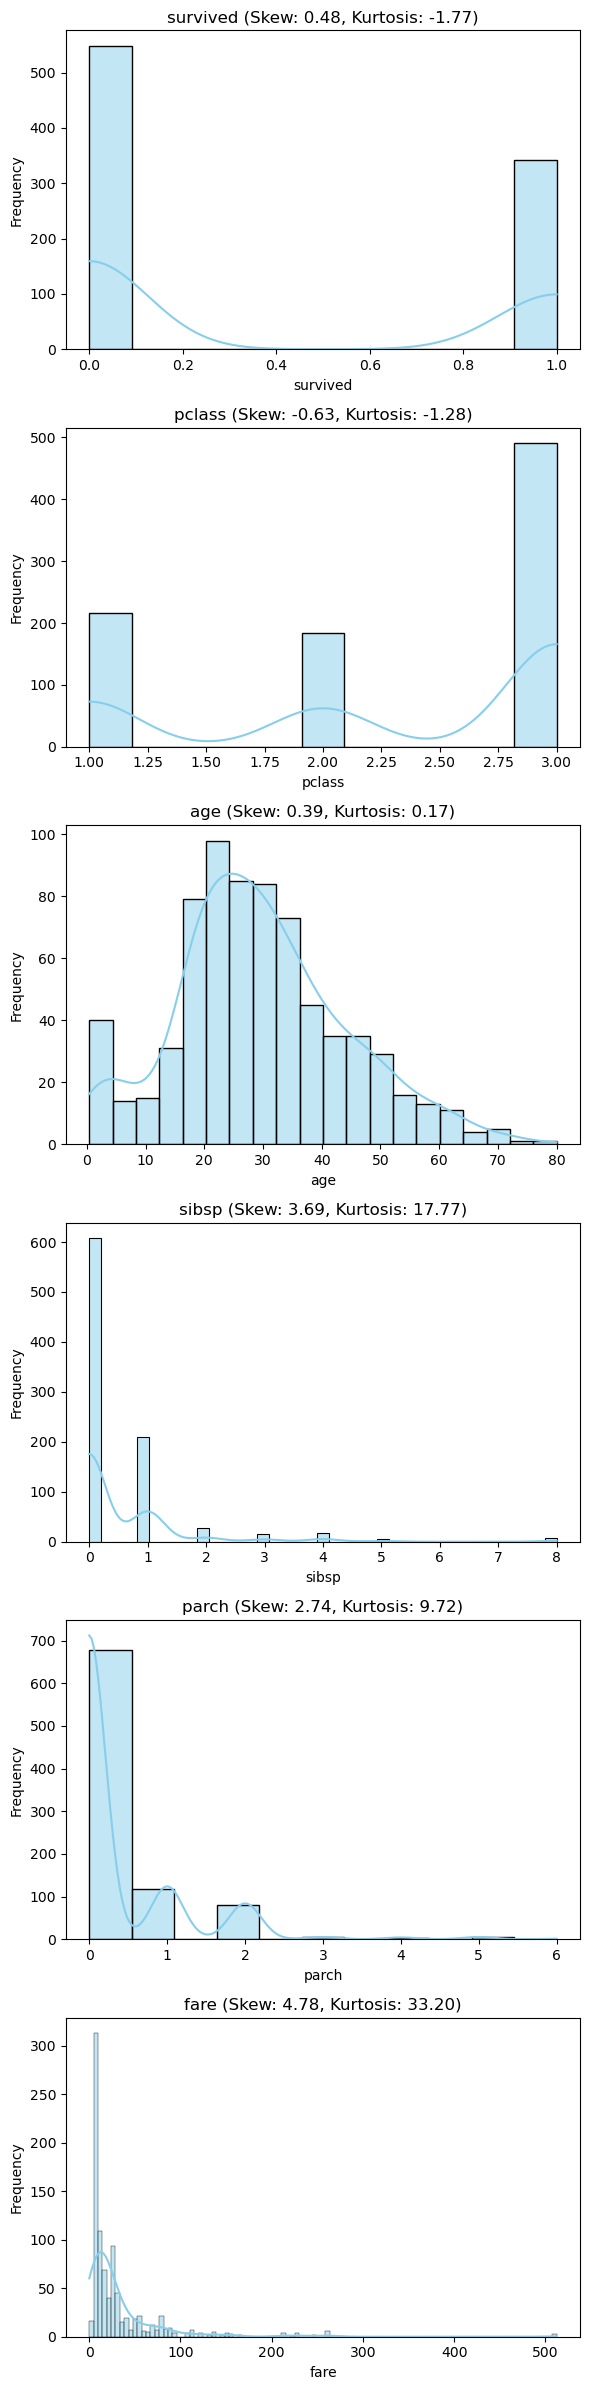

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
# Set up subplots
n = len(numeric_cols.to_list())
fig, axes = plt.subplots(nrows=n, figsize=(6, 4 * n))
axes = axes.flatten()
# Plot each numeric column
for i, col in enumerate(numeric_cols.to_list()):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='skyblue')
    
    # Compute skewness and kurtosis
    sk = skew(df[col].dropna())
    ku = kurtosis(df[col].dropna())
    
    # Annotate
    ax.set_title(f"{col} (Skew: {sk:.2f}, Kurtosis: {ku:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()



- Daat Cleaning
- Outliear Analysis
- Plan to Create models